In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))
from lib import resize_img


In [2]:
def notebook_imshow(img):
    plt.figure(figsize=(16, 8))
    # RGB img
    if len(img.shape) == 3:
        plt.imshow(img)
    # gray img
    else: 
        plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


In [3]:
# init (row, col) empty cells
class Cell:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.hlength = 1
        self.vlength = 1

    def set_hlength(self, length):
        self.hlength = length

    def set_vlength(self, length):
        self.vlength = length

    def __str__(self):
        return f"x={self.x}, y={self.y}, hlength={self.hlength}, vlength={self.vlength}"

img shape: (1440, 3440)


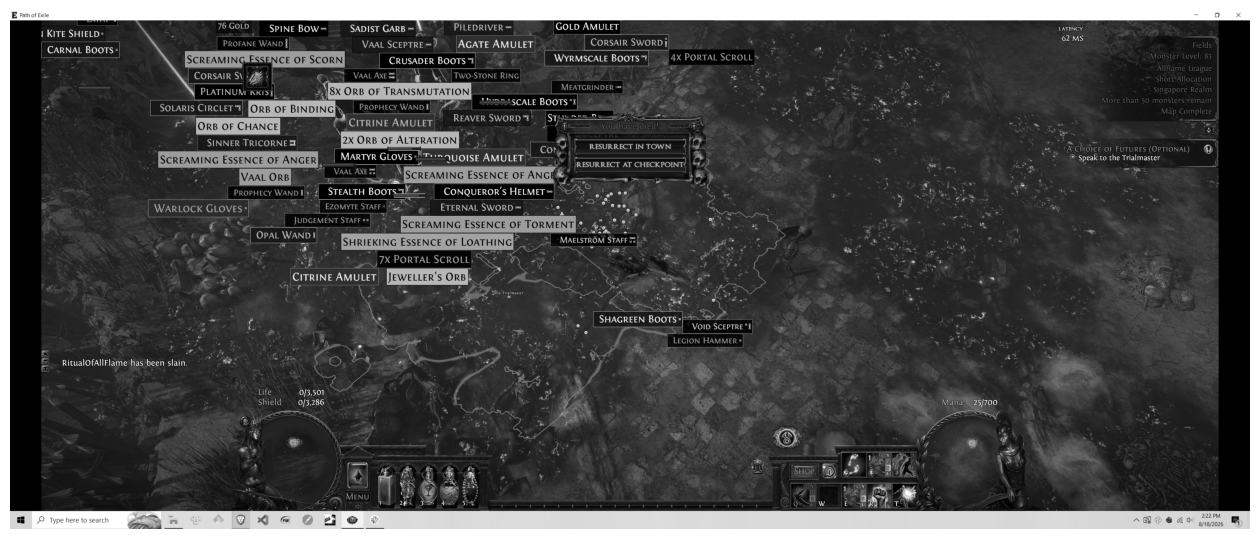

In [19]:
image = cv2.imread("../imgs/Capture4.PNG")
# resized_color_img, _ = resize_img(image[0:194, 0:319, :])
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) #shape:[R, C] = (row, col)
gray_img = gray_img.astype(np.int32)

cells = []
for i in range(0, gray_img.shape[0]):
    hcells = []
    for j in range(0, gray_img.shape[1]):
        hcells.append(Cell(j, i))
    cells.append(hcells)

print(f'img shape: {gray_img.shape}')
notebook_imshow(gray_img)

In [20]:
gray_img[564:566, 849:853]

array([[129, 129, 130, 129],
       [  8,  11,  22,  22]], dtype=int32)

In [21]:
# find all subarrays with identical elements in the horizontal direction
# first, for every row, compare ith & ith+1 pixels
horizontal_diff = np.abs(gray_img[:, :-1] - gray_img[:, 1:]) > 2 # shape: (row, col - 1)
print(horizontal_diff[564:566, 849:853])
# append an offset column (all valued 1) at the start & end of the diff array
offset = np.ones(horizontal_diff.shape[0])
horizontal_diff = np.column_stack((offset, horizontal_diff, offset)) # shape: (row, col + 1)
# offset = np.ones(horizontal_diff.shape[1])
# horizontal_diff = np.vstack((offset, horizontal_diff, offset))
horizontal_diff[564:566, 849:853]

[[False False False False]
 [ True  True False  True]]


array([[0., 0., 0., 0.],
       [0., 1., 1., 0.]])

In [22]:
# find non zero indices in each row
# this could also viewed as finding the start index of all subarrays that have the same elements
# thanks to the offset column ealier, we won't miss the first subarray
hline_start_indices = [np.flatnonzero(row) for row in horizontal_diff] # list of arrays with varies length (`row` arrays, max `col` + 1 elements)
hline_start_indices

[array([   0, 3440]),
 array([   0, 3440]),
 array([   0, 3440]),
 array([   0, 3440]),
 array([   0, 3440]),
 array([   0,    4,    5,    8,    9,   10,   12,   14,   15,   17,   18,
          19,   20, 3440]),
 array([   0,    4,    5,    6,    7,    8,    9,   10,   11,   12,   13,
          14,   15,   16,   17,   18,   19,   20, 3440]),
 array([   0,    4,    5,    6,    7,    9,   10,   11,   12,   13,   14,
          15,   16,   18,   19,   20, 3440]),
 array([   0,    5,    6,    7,    8,    9,   10,   11,   12,   13,   14,
          17,   18,   19,   20, 3345, 3355, 3402, 3403, 3404, 3412, 3413,
        3414, 3440]),
 array([   0,    5,    6,    7,    8,    9,   10,   11,   12,   13,   15,
          16,   17,   18,   19,   20,   28,   29,   32,   33,   34,   47,
          48,   49,   50,   70,   71,   72,   73,   74,   78,   79,   83,
          84,   85,   93,   94,   95,   96,   97,   98,   99, 3345, 3346,
        3354, 3355, 3402, 3403, 3404, 3405, 3411, 3412, 3413, 3414, 34

In [23]:
# find length of the subarrays by subtracting the start index of the next array to the it's previous array
hline_length = [row[1:] - row[:-1] for row in hline_start_indices]
hline_length[88]
for i, arr in enumerate(hline_start_indices):
    for j in range(0, len(arr) - 1):
        cells[i][arr[j]].set_hlength(hline_length[i][j])
print(cells[250][389])

x=389, y=250, hlength=256, vlength=1


In [24]:
# next, find all subarrays with identical elements in the vertical direction
vertical_diff = np.abs(gray_img[1:, :] - gray_img[:-1, :]) > 2
print(gray_img[248:308, 389])
vertical_diff[248:308, 389]

[ 40  41 180 180 180 180 180 180 180 180 180 180 180 180 180 180 180 180
 180 180 180 180 180 180 180 180 180 180 180 180 180 180 180 180 180 180
 180 180 180 180 180 180 180 180 180 180  40  40  40  38  38  38  37  37
  36  35  35  35  35  34]


array([False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [25]:
offset = np.ones(vertical_diff.shape[1])
vertical_diff = np.vstack((offset, vertical_diff, offset))
vertical_diff.shape

(1441, 3440)

In [26]:
vertical_diff[:, 87]

array([1., 0., 0., ..., 0., 1., 1.], shape=(1441,))

In [27]:
vline_start_indices = [np.flatnonzero(c) for c in vertical_diff.T]
len(vline_start_indices)

3440

In [28]:
vline_length = [c[1:] - c[:-1] for c in vline_start_indices]
vline_length
for i, arr in enumerate(vline_start_indices):
    for j in range(0, len(arr) - 1):
        cells[arr[j]][i].set_vlength(vline_length[i][j])
print(cells[564][762])

x=762, y=564, hlength=1, vlength=1


In [29]:
print(cells[859][1866])
print(cells[860][1866])
print(cells[859][1867])

x=1866, y=859, hlength=1, vlength=1
x=1866, y=860, hlength=1, vlength=37
x=1867, y=859, hlength=192, vlength=1


In [30]:
MINIMUM_CURRENCY_BOX_WIDTH = 120
MAXIMUM_CURRENCY_BOX_WIDTH = 500
MINIMUM_CURRENCY_BOX_HEIGHT = 30
MAXIMUM_CURRENCY_BOX_HEIGHT = 60

x=1509, y=29, hlength=185, vlength=38
x=692, y=30, hlength=191, vlength=44
x=917, y=30, hlength=208, vlength=44
x=1254, y=35, hlength=141, vlength=34
x=1594, y=68, hlength=234, vlength=45
x=1595, y=69, hlength=232, vlength=42
x=1238, y=70, hlength=219, vlength=49
x=1239, y=71, hlength=217, vlength=47
x=87, y=88, hlength=217, vlength=45
x=1828, y=109, hlength=238, vlength=44
x=1829, y=110, hlength=236, vlength=42
x=1483, y=112, hlength=289, vlength=44
x=484, y=113, hlength=446, vlength=48
x=1485, y=113, hlength=175, vlength=42
x=485, y=114, hlength=444, vlength=46
x=1025, y=119, hlength=266, vlength=44
x=1026, y=120, hlength=264, vlength=42
x=494, y=161, hlength=150, vlength=44
x=495, y=162, hlength=149, vlength=42
x=881, y=201, hlength=400, vlength=50
x=882, y=202, hlength=398, vlength=47
x=512, y=206, hlength=133, vlength=43
x=1281, y=233, hlength=293, vlength=45
x=1282, y=234, hlength=291, vlength=43
x=389, y=250, hlength=256, vlength=44
x=660, y=250, hlength=244, vlength=49
x=390, y

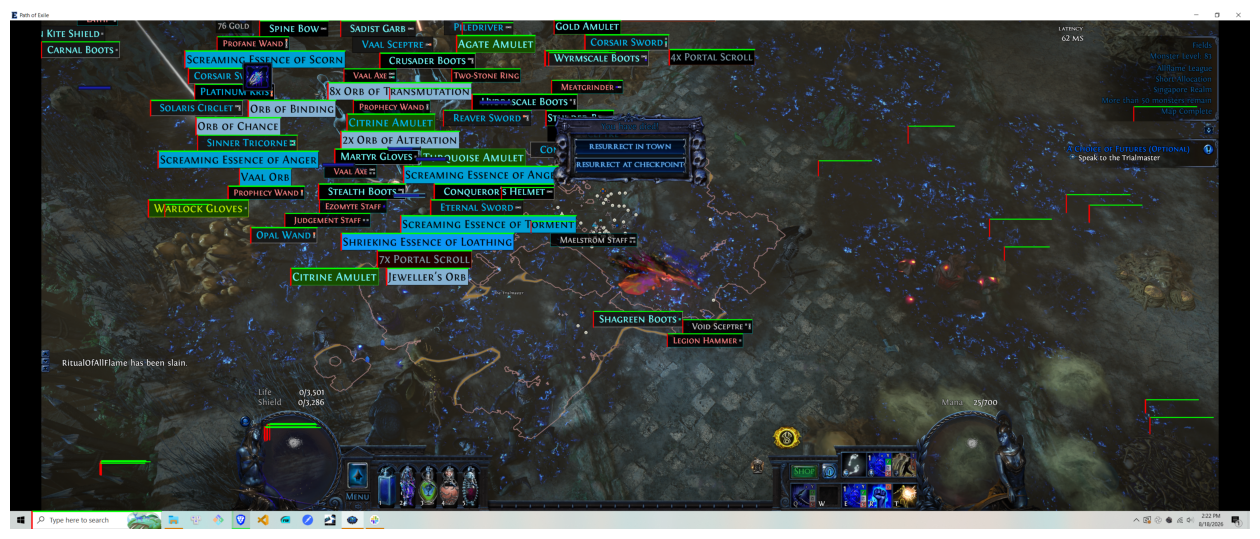

In [31]:
img = image.copy()
for i in range(0, img.shape[0]):
    for j in range(0, img.shape[1]):
        cell = cells[i][j]
        if MAXIMUM_CURRENCY_BOX_WIDTH > cell.hlength > MINIMUM_CURRENCY_BOX_WIDTH and MAXIMUM_CURRENCY_BOX_HEIGHT > cell.vlength > MINIMUM_CURRENCY_BOX_HEIGHT:
            print(cell)
            cv2.line(img, (j, i), (j + cell.hlength, i), (0, 255, 0), 2)
            cv2.line(img, (j, i), (j, i + cell.vlength), (255, 0, 0), 2)
        if cell.hlength == 1 and cell.vlength == 1:
            if i + 1>= img.shape[0] or j+1 >= img.shape[1]:
                continue
            if MAXIMUM_CURRENCY_BOX_HEIGHT > cells[i+1][j].vlength > MINIMUM_CURRENCY_BOX_HEIGHT and MAXIMUM_CURRENCY_BOX_WIDTH > cells[i][j+1].hlength > MINIMUM_CURRENCY_BOX_WIDTH:
                cv2.line(img, (j, i), (j + cells[i][j+1].hlength, i), (0, 255, 0), 2)
                cv2.line(img, (j, i), (j, i + cells[i+1][j].vlength), (255, 0, 0), 2)

success = cv2.imwrite('output_image.png', img)
notebook_imshow(img)